# Tarea 2: Supervivencia

Somos el equipo 5, conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez


## Trabajo de clase

Seleccione **una** de las siguientes bases de datos:

- SUPPORT
- METABRIC
- Rotterdam & GBSG
- FLCHAIN

### Instrucciones

1. Identifique las covariables, el tiempo observado y el indicador de evento.

2. Divida la base de datos en conjuntos de:
   - Entrenamiento
   - Validación
   - Prueba

3. Ajuste los siguientes modelos utilizando la misma partición de los datos:
   - Modelo de riesgos proporcionales de Cox tradicional.
   - Modelo DeepSurv utilizando PyCox.

4. Evalúe ambos modelos sobre el conjunto de prueba mediante el C-index.

5. Para el modelo DeepSurv, presente:
   - Gráfica de la pérdida de entrenamiento y validación.
   - Curvas de supervivencia estimadas para al menos tres individuos.

6. Presente una tabla comparativa con el C-index de ambos modelos.

7. Escriba una conclusión breve indicando:
   - Qué modelo obtuvo mejor desempeño.
   - Si DeepSurv produjo una mejora relevante frente al modelo de Cox.
   - Qué posibles razones explican los resultados obtenidos.

### Entrega

Entregue el notebook ejecutado, incluyendo el código, las gráficas, la tabla comparativa y la interpretación de los resultados.


### Descripción del problema

El problema central de esta tarea es predecir el tiempo de supervivencia de un conjunto de pacientes, utilizando un modelo de análisis de supervivencia. El objetivo es determinar qué modelo predictivo es más preciso al evaluar el riesgo de que ocurra un evento de interés (en este caso, la muerte del paciente).

### Metodología

- Identificación de variables (covariables, tiempo, evento)
- Partición de los datos:
    - entrenamiento de los datos
    - validación
    - prueba
- Ajusto de modelos
- Evaluación



Primero cargaremos nuestras librerías:

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import ipywidgets
from IPython.display import display

%matplotlib inline

Cargamos support:

In [36]:
from pycox import datasets
df = datasets.support.read_df()  # Carga el dataset SUPPORT
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
0,82.709961,1.0,2.0,1.0,0.0,0.0,0.0,160.0,55.0,16.0,38.195309,142.0,19.000000,1.099854,30.0,1
1,79.660950,1.0,0.0,1.0,0.0,0.0,1.0,54.0,67.0,16.0,38.000000,142.0,10.000000,0.899902,1527.0,0
2,23.399990,1.0,2.0,3.0,0.0,0.0,1.0,87.0,144.0,45.0,37.296879,130.0,5.199219,1.199951,96.0,1
3,53.075989,1.0,4.0,3.0,0.0,0.0,0.0,55.0,100.0,18.0,36.000000,135.0,8.699219,0.799927,892.0,0
4,71.794983,0.0,1.0,1.0,0.0,0.0,0.0,65.0,135.0,40.0,38.593750,146.0,0.099991,0.399963,7.0,1


Solo las variables de duración y evento tienen un nombre descriptivo. Las demás no lo tienen. Hacemos un análisis exploratorio rápido y sencillo:

In [37]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Bike Sharing EDA Report")
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 29446.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

De esto tenemos que:
- x7 y x8  se distribuyen de forma bi-modal
- la matriz de correlación no muestra altas o bajas correlaciones.

Ahora vamos a separar las columnas features de nuestras columnas de duración y evento:

In [38]:
feature_cols = [col for col in df.columns if col not in ['duration', 'event']]
time_col = 'duration'
event_col = 'event'

In [39]:
X = df[feature_cols].copy()
y_time = df[time_col]
y_event = df[event_col]

Separamos en conjuntos de entrenamiento y prueba.

In [40]:
X_train, X_temp, y_time_train, y_time_temp, y_event_train, y_event_temp = train_test_split(
    X, y_time, y_event, test_size=0.3, random_state=42, stratify=y_event
)

X_val, X_test, y_time_val, y_time_test, y_event_val, y_event_test = train_test_split(
    X_temp, y_time_temp, y_event_temp, test_size=0.5, random_state=42, stratify=y_event_temp
)

Estandarizamos:

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Preparar datos para lifelines
train_data_cox = pd.DataFrame(X_train_scaled, columns=feature_cols)
train_data_cox['duration'] = y_time_train.values
train_data_cox['event'] = y_event_train.values

test_data_cox = pd.DataFrame(X_test_scaled, columns=feature_cols)
test_data_cox['duration'] = y_time_test.values
test_data_cox['event'] = y_event_test.values

# Ajustar modelo Cox con regularización
cox_model = CoxPHFitter(penalizer=0.1, l1_ratio=0.0)
cox_model.fit(train_data_cox, duration_col='duration', event_col='event')

# Calcular C-index en prueba
c_index_cox = cox_model.score(test_data_cox, scoring_method='concordance_index')

In [43]:
class DeepSurvRisk(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        
        # Capa de salida: un score de riesgo por individuo
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [44]:
input_dim = X_train_scaled.shape[1]
net = DeepSurvRisk(input_dim=input_dim, hidden_dims=(64, 32, 16), dropout=0.2)

# Crear el modelo Cox de PyCox
model_deepsurv = CoxPH(net, optimizer=torch.optim.Adam)
model_deepsurv.optimizer.set_lr(0.001)

# Convertir datos a arrays numpy
x_train_np = X_train_scaled.astype('float32')
time_train_np = y_time_train.values.astype('float32')
status_train_np = y_event_train.values.astype('float32')

x_val_np = X_val_scaled.astype('float32')
time_val_np = y_time_val.values.astype('float32')
status_val_np = y_event_val.values.astype('float32')

In [45]:
log_deepsurv = model_deepsurv.fit(
    input=x_train_np,
    target=(time_train_np, status_train_np),
    batch_size=128,
    epochs=50,
    val_data=(x_val_np, (time_val_np, status_val_np)),
    verbose=True
)

0:	[0s / 0s],		train_loss: 4.4057,	val_loss: 6.6217
1:	[0s / 0s],		train_loss: 4.3076,	val_loss: 6.5976
2:	[0s / 0s],		train_loss: 4.2954,	val_loss: 6.5918
3:	[0s / 0s],		train_loss: 4.2624,	val_loss: 6.5791
4:	[0s / 0s],		train_loss: 4.2613,	val_loss: 6.5768
5:	[0s / 0s],		train_loss: 4.2549,	val_loss: 6.5717
6:	[0s / 0s],		train_loss: 4.2432,	val_loss: 6.5687
7:	[0s / 0s],		train_loss: 4.2335,	val_loss: 6.5652
8:	[0s / 0s],		train_loss: 4.2308,	val_loss: 6.5661
9:	[0s / 0s],		train_loss: 4.2244,	val_loss: 6.5637
10:	[0s / 1s],		train_loss: 4.2268,	val_loss: 6.5612
11:	[0s / 1s],		train_loss: 4.2232,	val_loss: 6.5601
12:	[0s / 1s],		train_loss: 4.2106,	val_loss: 6.5637
13:	[0s / 1s],		train_loss: 4.2191,	val_loss: 6.5654
14:	[0s / 1s],		train_loss: 4.2039,	val_loss: 6.5638
15:	[0s / 1s],		train_loss: 4.2053,	val_loss: 6.5642
16:	[0s / 2s],		train_loss: 4.2074,	val_loss: 6.5628
17:	[0s / 2s],		train_loss: 4.2025,	val_loss: 6.5631
18:	[0s / 2s],		train_loss: 4.2075,	val_loss: 6.5646
19:

In [46]:
model_deepsurv.compute_baseline_hazards()

# Predecir curvas de supervivencia para prueba
x_test_np = X_test_scaled.astype('float32')
surv_test = model_deepsurv.predict_surv_df(x_test_np)

# Calcular C-index
ev = EvalSurv(surv_test, y_time_test.values, y_event_test.values)
c_index_deepsurv = ev.concordance_td()
print(f"C-index del modelo DeepSurv: {c_index_deepsurv:.4f}")

C-index del modelo DeepSurv: 0.6077


<Axes: >

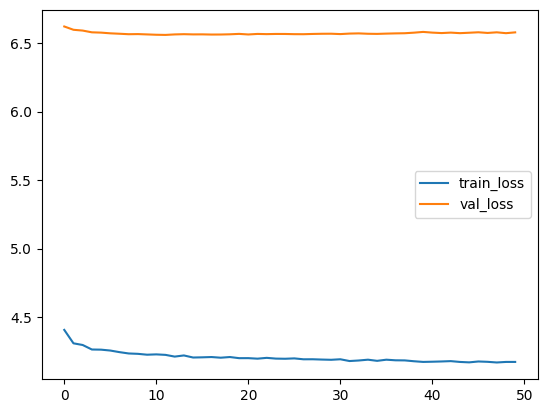

In [47]:
log_deepsurv.plot()

In [48]:
np.random.seed(42)
n_curves = min(5, len(surv_test.columns))
idx_selected = np.random.choice(range(n_curves), n_curves, replace=False)

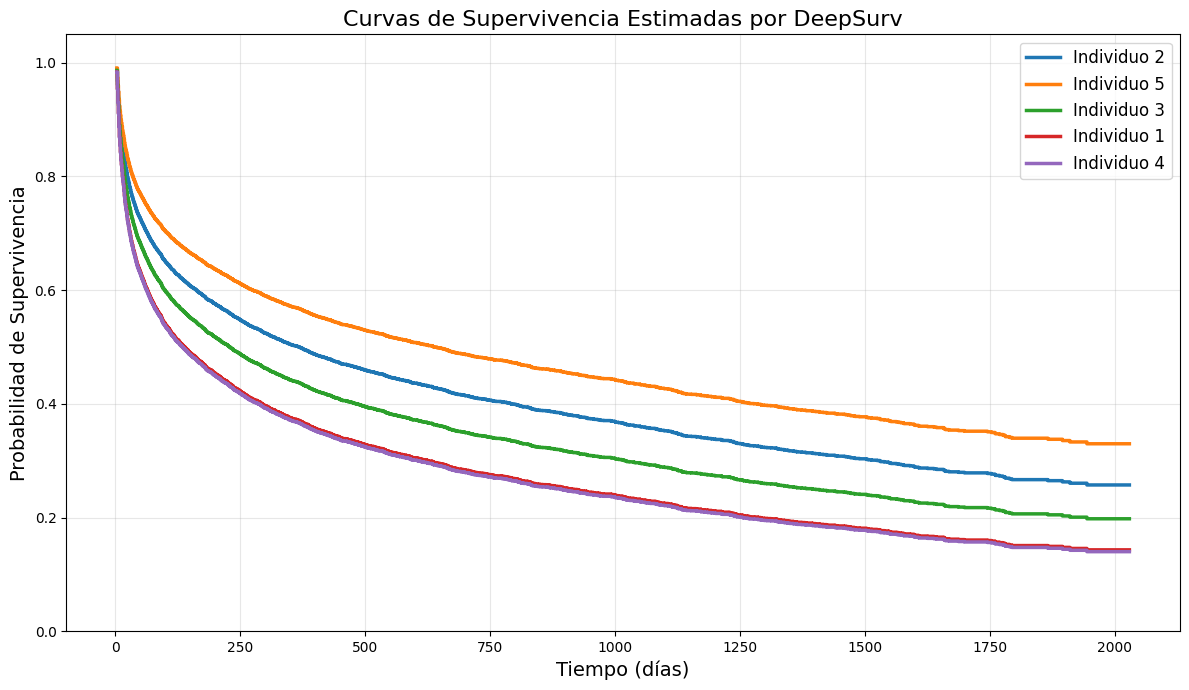

In [49]:
plt.figure(figsize=(12, 7))

times = surv_test.index.values

for i, idx in enumerate(idx_selected):
    survival_curve = surv_test.iloc[:, idx].values
    plt.step(times, survival_curve, where='post', 
             label=f'Individuo {idx+1}', linewidth=2.5)

plt.xlabel('Tiempo (días)', fontsize=14)
plt.ylabel('Probabilidad de Supervivencia', fontsize=14)
plt.title('Curvas de Supervivencia Estimadas por DeepSurv', fontsize=16)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

In [50]:
print("\n" + "="*50)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*50)

comparison_df = pd.DataFrame({
    'Modelo': ['Cox Tradicional', 'DeepSurv (PyCox)'],
    'C-index': [c_index_cox, c_index_deepsurv],
    'Mejora': ['-', f'{(c_index_deepsurv - c_index_cox)*100:.2f}%']
})

print("\nTabla 1: Comparación de C-index en conjunto de prueba")
print(comparison_df.to_string(index=False))



TABLA COMPARATIVA DE RESULTADOS

Tabla 1: Comparación de C-index en conjunto de prueba
          Modelo  C-index Mejora
 Cox Tradicional 0.556051      -
DeepSurv (PyCox) 0.607716  5.17%


### Conclusiones

En general, las arquitecturas de red pueden capturar relaciones no lineales y complejas entre variables por lo que tiene sentido (por lo que vimos en el EDA) de que al tener columnas con poca correlación, la arquitectura de red de DeepSurv sea mejor que un modelo lineal como lo es el de Cox.